In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../artifacts/sentiment_analysis.csv')

In [3]:
data.head()

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


## Data Preprocessing

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7920 entries, 0 to 7919
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      7920 non-null   int64 
 1   label   7920 non-null   int64 
 2   tweet   7920 non-null   object
dtypes: int64(2), object(1)
memory usage: 185.8+ KB


In [6]:
data.duplicated().sum()

0

In [7]:
data.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

### Text Preprocessing
- Convert Uppercase to Lowercase
- Remove Links
- Remove Punctuations (e.g. ?, !, #, ^, )
- Remove Stopwords (e.g. and,the,by,is,in)
- Remove numbers
- Stemming  (e.g. create - creating, creative, created, creates)

In [9]:
import re
import string

Convert UPPERCASE to lowercase

In [11]:
data['tweet'] = data['tweet'].apply(lambda x: " ".join(x.lower () for x in x.split()))
data['tweet'].head()

0    #fingerprint #pregnancy test https://goo.gl/h1...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
3    i'm wired i know i'm george i was made that wa...
4    what amazing service! apple won't even talk to...
Name: tweet, dtype: object

Remove links

In [13]:
data['tweet'] = data['tweet'].apply(lambda x: " ".join(re.sub(r'^https?:\/\/.*[\r\n]*', '',x,flags=re.MULTILINE) for x in x.split()))
data['tweet']

0       #fingerprint #pregnancy test  #android #apps #...
1       finally a transparant silicon case ^^ thanks t...
2       we love this! would you go? #talk #makememorie...
3       i'm wired i know i'm george i was made that wa...
4       what amazing service! apple won't even talk to...
                              ...                        
7915    live out loud #lol #liveoutloud #selfie #smile...
7916    we would like to wish you an amazing day! make...
7917    helping my lovely 90 year old neighbor with he...
7918    finally got my #smart #pocket #wifi stay conne...
7919    apple barcelona!!! #apple #store #bcn #barcelo...
Name: tweet, Length: 7920, dtype: object

Remove Punctuations

In [15]:
#List of punctutions inside the string module we imported previously
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [16]:
def remove_punctuations(text):
    for punctuation in string.punctuation:
        text = text.replace(punctuation, '')
    return text

In [17]:
data['tweet'] = data['tweet'].apply(remove_punctuations)
data['tweet'].head()

0    fingerprint pregnancy test  android apps beaut...
1    finally a transparant silicon case  thanks to ...
2    we love this would you go talk makememories un...
3    im wired i know im george i was made that way ...
4    what amazing service apple wont even talk to m...
Name: tweet, dtype: object

Remove numbers

In [19]:
#Before removing
data['tweet'].tail()

7915    live out loud lol liveoutloud selfie smile son...
7916    we would like to wish you an amazing day make ...
7917    helping my lovely 90 year old neighbor with he...
7918    finally got my smart pocket wifi stay connecte...
7919    apple barcelona apple store bcn barcelona trav...
Name: tweet, dtype: object

In [20]:
#after removing
data['tweet'] = data['tweet'].str.replace('\d+', '', regex = True)
data['tweet'].tail()

#number 90  in between lovely and year is gone

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\User\AppData\Local\Temp\ipykernel_19228\2194116503.py:2: SyntaxWarning: invalid escape sequence '\d'
  data['tweet'] = data['tweet'].str.replace('\d+', '', regex = True)


7915    live out loud lol liveoutloud selfie smile son...
7916    we would like to wish you an amazing day make ...
7917    helping my lovely  year old neighbor with her ...
7918    finally got my smart pocket wifi stay connecte...
7919    apple barcelona apple store bcn barcelona trav...
Name: tweet, dtype: object

Remove stopwords

In [22]:
!pip install nltk

In [23]:
import nltk   # nltk stands for natural language toolkit use this to filter stopwords

In [24]:
nltk.download('stopwords', download_dir ='../static/model' )

[nltk_data] Downloading package stopwords to ../static/model...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [25]:
# get all the stop words to model.ipynb
with open('../static/model/corpora/stopwords/english', 'r') as file:
    stop_words = file.read().splitlines()
stop_words[:5]

['a', 'about', 'above', 'after', 'again']

In [26]:
#remove all the stopwords
data['tweet'] = data['tweet'].apply(lambda x: " ".join (x for x in x.split() if x not in stop_words))
data['tweet'].head()

0    fingerprint pregnancy test android apps beauti...
1    finally transparant silicon case thanks uncle ...
2    love would go talk makememories unplug relax i...
3    im wired know im george made way iphone cute d...
4    amazing service apple wont even talk question ...
Name: tweet, dtype: object

Stemming   (e.g. create - creating,created)    

In [28]:
# we can use same nltk library for this
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [29]:
#Stemming
data['tweet'] = data['tweet'].apply(lambda x: " ".join(ps.stem(x) for x in x.split()))
data['tweet'].head()

0    fingerprint pregnanc test android app beauti c...
1    final transpar silicon case thank uncl yay son...
2    love would go talk makememori unplug relax iph...
3    im wire know im georg made way iphon cute dave...
4    amaz servic appl wont even talk question unles...
Name: tweet, dtype: object

### Completed Proprocessed Data

In [31]:
data

,id,label,tweet
0,1,0,fingerprint pregnanc test android app beauti c...
1,2,0,final transpar silicon case thank uncl yay son...
2,3,0,love would go talk makememori unplug relax iph...
3,4,0,im wire know im georg made way iphon cute dave...
4,5,1,amaz servic appl wont even talk question unles...
...,...,...,...
7915,7916,0,live loud lol liveoutloud selfi smile soni mus...
7916,7917,0,would like wish amaz day make everi minut coun...
7917,7918,0,help love year old neighbor ipad morn made rea...
7918,7919,0,final got smart pocket wifi stay connect anyti...


## Building Vocabulary

In [33]:
!pip install iPython

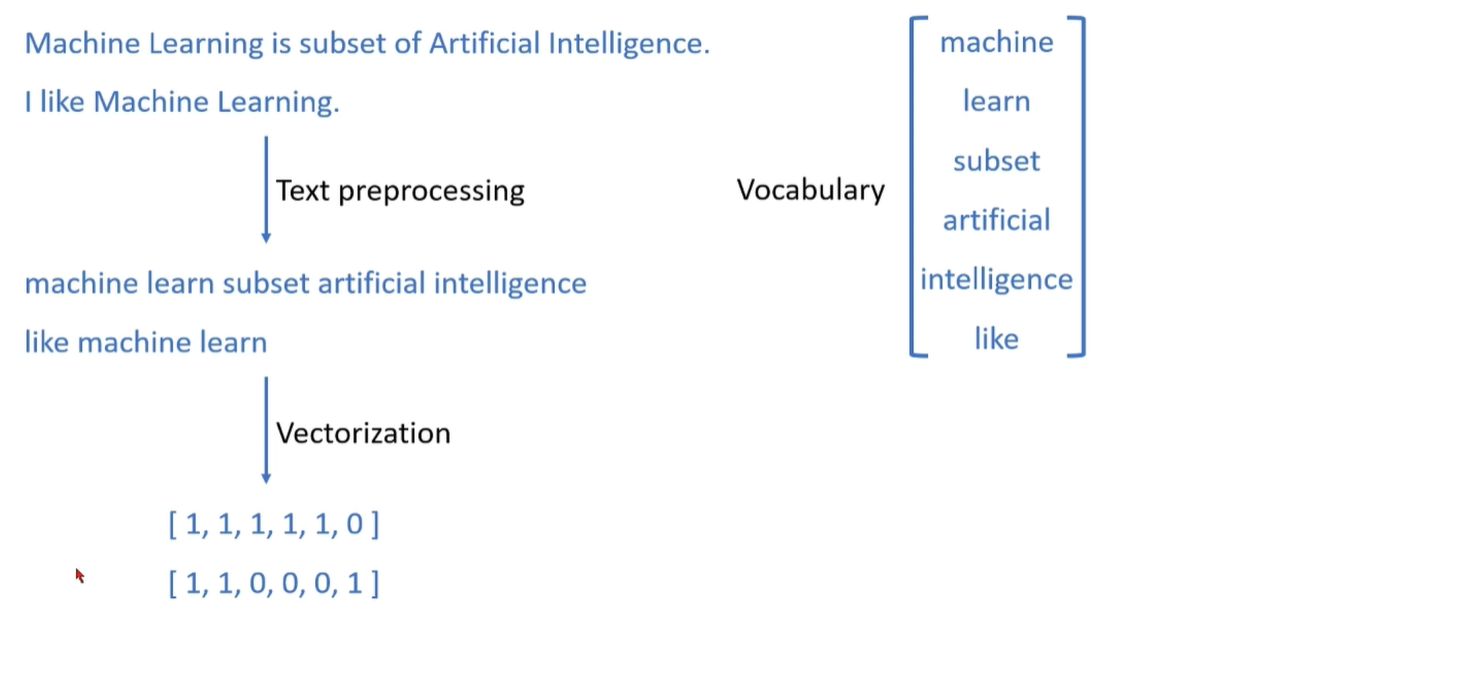

In [34]:
from IPython.display import Image
Image(filename='../images/mlp1.png', width = 600)

In [35]:
from collections import Counter
vocab = Counter()

In [36]:
"""  Get the count of each word existance  example
vocab.update(['java', 'python', 'python', 'c++' ])
vocab       """

"  Get the count of each word existance  example\nvocab.update(['java', 'python', 'python', 'c++' ])\nvocab       "

In [37]:
vocab

Counter()

In [38]:
# Pass each sentence in our dataset to vocab library
for sentence in data['tweet']:
    vocab.update(sentence.split())

In [39]:
#vocab

In [40]:
len(vocab)

15949

In [41]:
data.shape

(7920, 3)

In [42]:
# According to above can observe that our model is going to be absolutely overfitted
# Inorder to avoid that here im taking only the keys that have values more than 10

tokens = [key for key in vocab if vocab[key]> 10]
#tokens

In [43]:
len(tokens)

1145

#### Save new vocabulary to a new file

In [45]:
def save_vocabulary(lines,filename):
    data = '\n'.join(lines)
    file = open(filename, 'w',encoding="utf-8")
    file.write(data)
    file.close()
save_vocabulary(tokens, '../static/model/vocabulary.text')

## Divide Dataset

In [47]:
data

,id,label,tweet
0,1,0,fingerprint pregnanc test android app beauti c...
1,2,0,final transpar silicon case thank uncl yay son...
2,3,0,love would go talk makememori unplug relax iph...
3,4,0,im wire know im georg made way iphon cute dave...
4,5,1,amaz servic appl wont even talk question unles...
...,...,...,...
7915,7916,0,live loud lol liveoutloud selfi smile soni mus...
7916,7917,0,would like wish amaz day make everi minut coun...
7917,7918,0,help love year old neighbor ipad morn made rea...
7918,7919,0,final got smart pocket wifi stay connect anyti...


In [48]:
X = data['tweet']
y = data['label']

In [49]:
!pip install scikit-learn

In [50]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2)

In [51]:
X_test.shape

(1584,)

In [52]:
X_train.shape

(6336,)

In [53]:
y_test.shape

(1584,)

In [54]:
y_train.shape

(6336,)

## Vectorization

In [56]:
def vectorizer(data_set, vocabulary):
    vectorized_list = []

    for sentence in data_set:
        sentence_list = np.zeros(len(vocabulary))

        for i in range (len(vocabulary)):
            if vocabulary[i] in sentence.split():
                sentence_list[i] = 1
        vectorized_list.append(sentence_list)
    vectorized_list_new = np.asarray(vectorized_list, dtype=np.float32)

    return vectorized_list_new

In [57]:
vectorized_X_train = vectorizer(X_train,tokens)  # as vocabulary we use tokens preprocessed data

In [58]:
vectorized_X_test = vectorizer(X_test,tokens)

### To Train and Evaluate the models we use Variables such as

- vectorized_X_train
- vectorized_X_test
- y_train
- y_test


.

Observed that this data set is almost imbalanced

In [61]:
y_train.value_counts()

label
0    4738
1    1598
Name: count, dtype: int64

So according to above if we train in this state the model is biased to positive predictions since data set is unbalanced

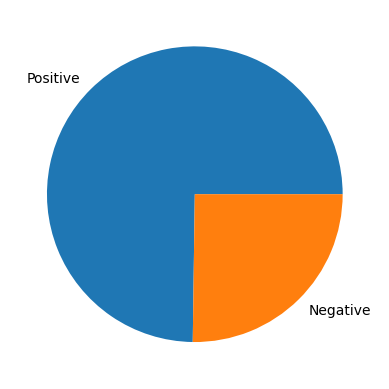

In [63]:
#Check with plotting the data set
plt.pie(np.array([y_train.value_counts()[0],y_train.value_counts()[1]]), labels=['Positive','Negative'])
plt.show()

### Handle imbalanced dataset

In [65]:
!pip install imbalanced-learn

In [66]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
vectorized_X_train_smote, y_train_smote = smote.fit_resample(vectorized_X_train,y_train)
print(vectorized_X_train_smote.shape, y_train_smote.shape)

(9476, 1145) (9476,)


In [67]:
# After smote 

y_train_smote.value_counts()

label
1    4738
0    4738
Name: count, dtype: int64

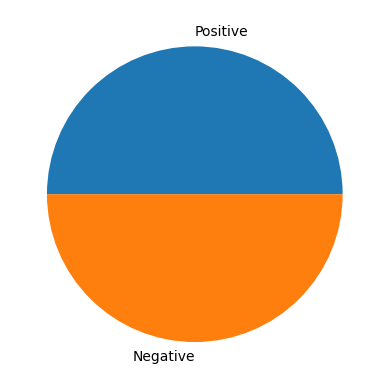

In [68]:
# To illustrate
plt.pie(np.array([y_train_smote.value_counts()[0],y_train_smote.value_counts()[1]]), labels = ['Positive','Negative'])
plt.show()

### Complete Set of Variables after SMOT required to train the model

#### For train
- vectorized_X_train_smote
- y_train_smote

#### For test
- vectorized_X_test
- y_test

## Model Training and Evaluation

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

### A Function to Evaluate the model Using all algorithms

In [73]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

Testing Score

In [75]:
def training_score(y_actual,y_predicted):
    accuracy = round(accuracy_score(y_actual,y_predicted), 3)
    f1 = round(f1_score(y_actual,y_predicted), 3)
    precision = round(precision_score(y_actual,y_predicted), 3)
    recall= round(recall_score(y_actual,y_predicted), 3)
    print(f'Testing Scores:\n\tAccuracy = {accuracy}\n\tF1 Score = {f1}\n\tPrecision Score = {precision}\n\tRecall Score = {recall}')

Validation Score

In [77]:
def validation_score(y_test,y_pred):
    accuracy = round(accuracy_score(y_test,y_pred), 3)
    f1 = round(f1_score(y_test,y_pred), 3)
    precision = round(precision_score(y_test,y_pred), 3)
    recall = round(recall_score(y_test,y_pred), 3)
    print(f'Validation Score:\n\tAccuracy = {accuracy}\n\tF1 Score = {f1}\n\tPrecision Score = {precision}\n\tRecall Score = {recall}')

## Logistic Regression 

In [79]:
lr = LogisticRegression()
lr.fit(vectorized_X_train_smote,y_train_smote)

LogisticRegression()

In [80]:
y_pred = lr.predict(vectorized_X_train_smote)
y_pred

array([1, 1, 0, ..., 1, 1, 1], dtype=int64)

In [81]:
y_train_smote

0       1
1       1
2       0
3       0
4       0
       ..
9471    1
9472    1
9473    1
9474    1
9475    1
Name: label, Length: 9476, dtype: int64

Training Score of model built from LR 

In [83]:
training_score(y_train_smote,y_pred)

Testing Scores:
	Accuracy = 0.941
	F1 Score = 0.943
	Precision Score = 0.919
	Recall Score = 0.967


Traning Score of model built from LR

In [85]:
y_test_pred = lr.predict(vectorized_X_test)
y_test_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [86]:
validation_score(y_test, y_test_pred)

Validation Score:
	Accuracy = 0.879
	F1 Score = 0.789
	Precision Score = 0.744
	Recall Score = 0.841


## Naive Bayes

In [88]:
nb = MultinomialNB()
nb.fit(vectorized_X_train_smote, y_train_smote)

y_train_pred = nb.predict(vectorized_X_train_smote)

y_test_pred = nb.predict(vectorized_X_test)

training_score(y_train_smote,y_train_pred)

validation_score(y_test, y_test_pred)

Testing Scores:
	Accuracy = 0.905
	F1 Score = 0.91
	Precision Score = 0.868
	Recall Score = 0.957
Validation Score:
	Accuracy = 0.869
	F1 Score = 0.787
	Precision Score = 0.703
	Recall Score = 0.895


## Decision Tree

In [90]:
dt = DecisionTreeClassifier()

dt.fit(vectorized_X_train_smote,y_train_smote)

y_train_pred = dt.predict(vectorized_X_train_smote)

y_test_pred = dt.predict(vectorized_X_test)

training_score(y_train_smote,y_train_pred)

validation_score(y_test,y_test_pred)

Testing Scores:
	Accuracy = 1.0
	F1 Score = 1.0
	Precision Score = 1.0
	Recall Score = 0.999
Validation Score:
	Accuracy = 0.821
	F1 Score = 0.658
	Precision Score = 0.682
	Recall Score = 0.636


## Random Forest

In [92]:
rf = RandomForestClassifier()

rf.fit(vectorized_X_train_smote,y_train_smote)

y_train_pred = rf.predict(vectorized_X_train_smote)

y_test_pred = rf.predict(vectorized_X_test)

training_score(y_train_smote,y_train_pred)

validation_score(y_test,y_test_pred)

Testing Scores:
	Accuracy = 1.0
	F1 Score = 1.0
	Precision Score = 0.999
	Recall Score = 1.0
Validation Score:
	Accuracy = 0.871
	F1 Score = 0.751
	Precision Score = 0.786
	Recall Score = 0.72


## Support Vector Machine

In [94]:
svm = SVC()

svm.fit(vectorized_X_train_smote, y_train_smote)

y_train_pred = svm.predict(vectorized_X_train_smote)

y_test_pred = svm.predict(vectorized_X_test)

training_score(y_train_smote,y_train_pred)

validation_score(y_test,y_test_pred)

Testing Scores:
	Accuracy = 0.978
	F1 Score = 0.979
	Precision Score = 0.961
	Recall Score = 0.997
Validation Score:
	Accuracy = 0.891
	F1 Score = 0.802
	Precision Score = 0.787
	Recall Score = 0.818


## Save the model

In [96]:
import pickle

with open('../static/model/model.pickle', 'wb') as file:
    pickle.dump(svm, file)